### Import necessary libraries

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils import shuffle
from skimage.transform import resize
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
import glob
import cv2

### Load datasets

In [83]:

green_area=glob.glob('green_area/*.jpg')
desert=glob.glob('desert/*.*')
cloudy=glob.glob('cloudy/*.jpg')

In [84]:

print(len(green_area))
print(len(desert))
print(len(cloudy))


1500
1131
1500


### Create a list with dataset

In [85]:
image=[]
label=[]


for i in green_area:
    img=cv2.imread(i)
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    img=cv2.resize(img,(128,128))
    image.append(img)
    label.append(0)

for i in desert:
    img=cv2.imread(i)
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    img=cv2.resize(img,(128,128))
    image.append(img)
    label.append(1)

for i in cloudy:
    img=cv2.imread(i)
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    img=cv2.resize(img,(128,128))
    image.append(img)
    label.append(2)

### Shuffling the data

In [86]:
image,label=shuffle(image,label,random_state=42)

### Visualizing some of the images 

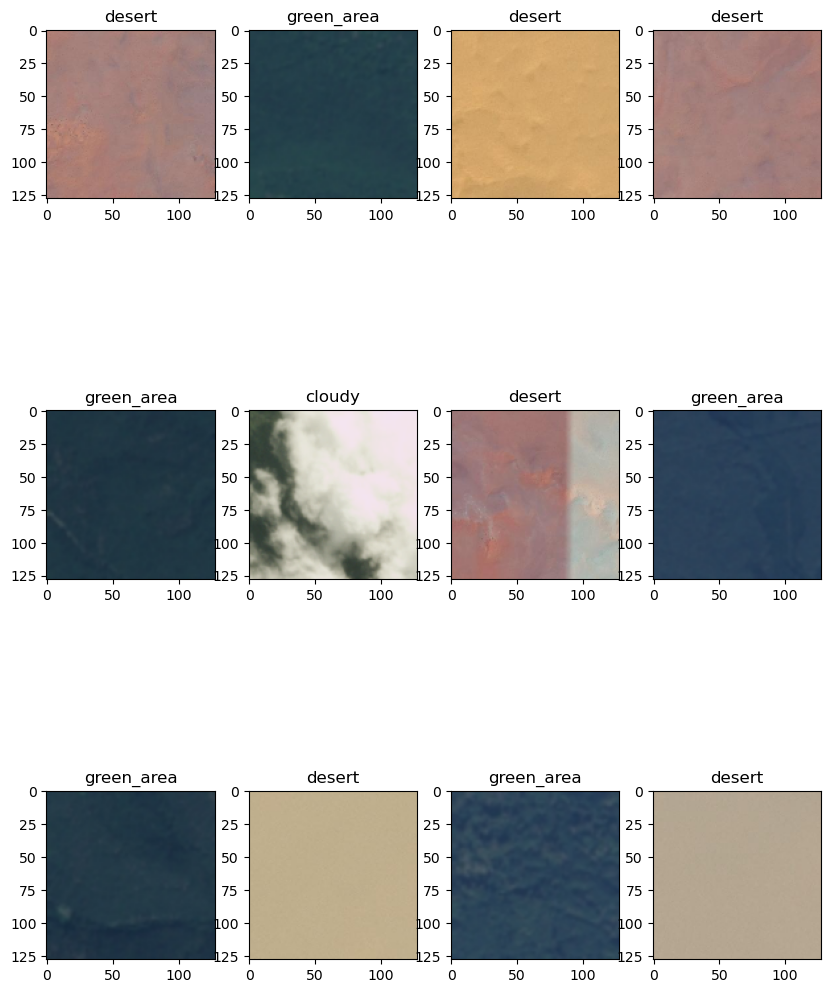

In [87]:
plt.figure(figsize=(10,14))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(image[i])
    if label[i]==0:
        plt.title('green_area')
    elif label[i]==1:
        plt.title('desert')
    else:
        plt.title('cloudy')

        
    

In [88]:
print('Images:',len(image))
print('Labels:',len(label))
print('Unique Labels:',set(label))

Images: 4131
Labels: 4131
Unique Labels: {0, 1, 2}


### Splitting features and targets

In [89]:
X=np.array(image)
X=X/255.0

In [90]:
y=np.array(label)

### Train test split

In [91]:
from sklearn.model_selection import train_test_split

In [92]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [93]:
X_train.shape

(3304, 128, 128, 3)

In [94]:
y_train.shape

(3304,)

### Model Creation

In [95]:
from tensorflow import keras

In [99]:
model=keras.models.Sequential([
    keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    keras.layers.MaxPool2D(),

    keras.layers.Conv2D(64,(3,3),activation='relu'),
    keras.layers.MaxPool2D(),

    keras.layers.Conv2D(128,(3,3),activation='relu'),
    keras.layers.MaxPool2D(),

    keras.layers.Flatten(),

    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dropout(0.05),

    keras.layers.Dense(3,activation='softmax')
    
])

In [100]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [101]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

### Model training

In [102]:
model.fit(X_train,y_train,epochs=30,validation_split=0.1)

Epoch 1/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 26s 245ms/step - accuracy: 0.8614 - loss: 0.3376 - val_accuracy: 0.9124 - val_loss: 0.2281
Epoch 2/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 21s 229ms/step - accuracy: 0.9341 - loss: 0.1857 - val_accuracy: 0.8882 - val_loss: 0.2461
Epoch 3/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 22s 232ms/step - accuracy: 0.9310 - loss: 0.1822 - val_accuracy: 0.9154 - val_loss: 0.1751
Epoch 4/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 21s 228ms/step - accuracy: 0.9378 - loss: 0.1669 - val_accuracy: 0.9335 - val_loss: 0.1845
Epoch 5/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 21s 230ms/step - accuracy: 0.9401 - loss: 0.1667 - val_accuracy: 0.9275 - val_loss: 0.1472
Epoch 6/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 22s 233ms/step - accuracy: 0.9257 - loss: 0.1695 - val_accuracy: 0.9456 - val_loss: 0.1235
Epoch 7/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 22s 237ms/step - accuracy: 0.9425 - loss: 0.1516 - val_accuracy: 0.9305 - val_loss: 0.1629
Epoch 8/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 52s 356ms/step - accuracy: 0.9452 - loss: 0.1423 - val_accu

In [103]:
training_loss,training_accuracy=model.evaluate(X_train,y_train)
print('training_Loss:',training_loss)
print('training_Accuracy:',training_accuracy)

104/104 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - accuracy: 0.9731 - loss: 0.0764
training_Loss: 0.07641898840665817
training_Accuracy: 0.9730629324913025


In [104]:
testing_loss,testing_accuracy=model.evaluate(X_test,y_test)
print('Testing_Loss:',testing_loss)
print('Testing_Accuracy:',testing_accuracy)

26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.9722 - loss: 0.0780 
Testing_Loss: 0.0779767781496048
Testing_Accuracy: 0.9721886515617371


### Prediction

In [105]:
prediction=model.predict(X_test)

26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step 


In [106]:
pred=np.argmax(prediction,axis=1)

### Evaluation metrics

In [107]:
accuracy_score(y_test,pred)

0.9721886336154776

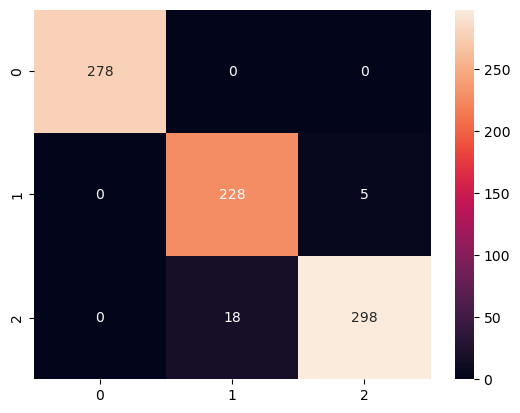

In [108]:
sns.heatmap(confusion_matrix(y_test,pred),annot=True,fmt='d')
plt.show()

In [109]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       278
           1       0.93      0.98      0.95       233
           2       0.98      0.94      0.96       316

    accuracy                           0.97       827
   macro avg       0.97      0.97      0.97       827
weighted avg       0.97      0.97      0.97       827



### Visualizing some of the predictions

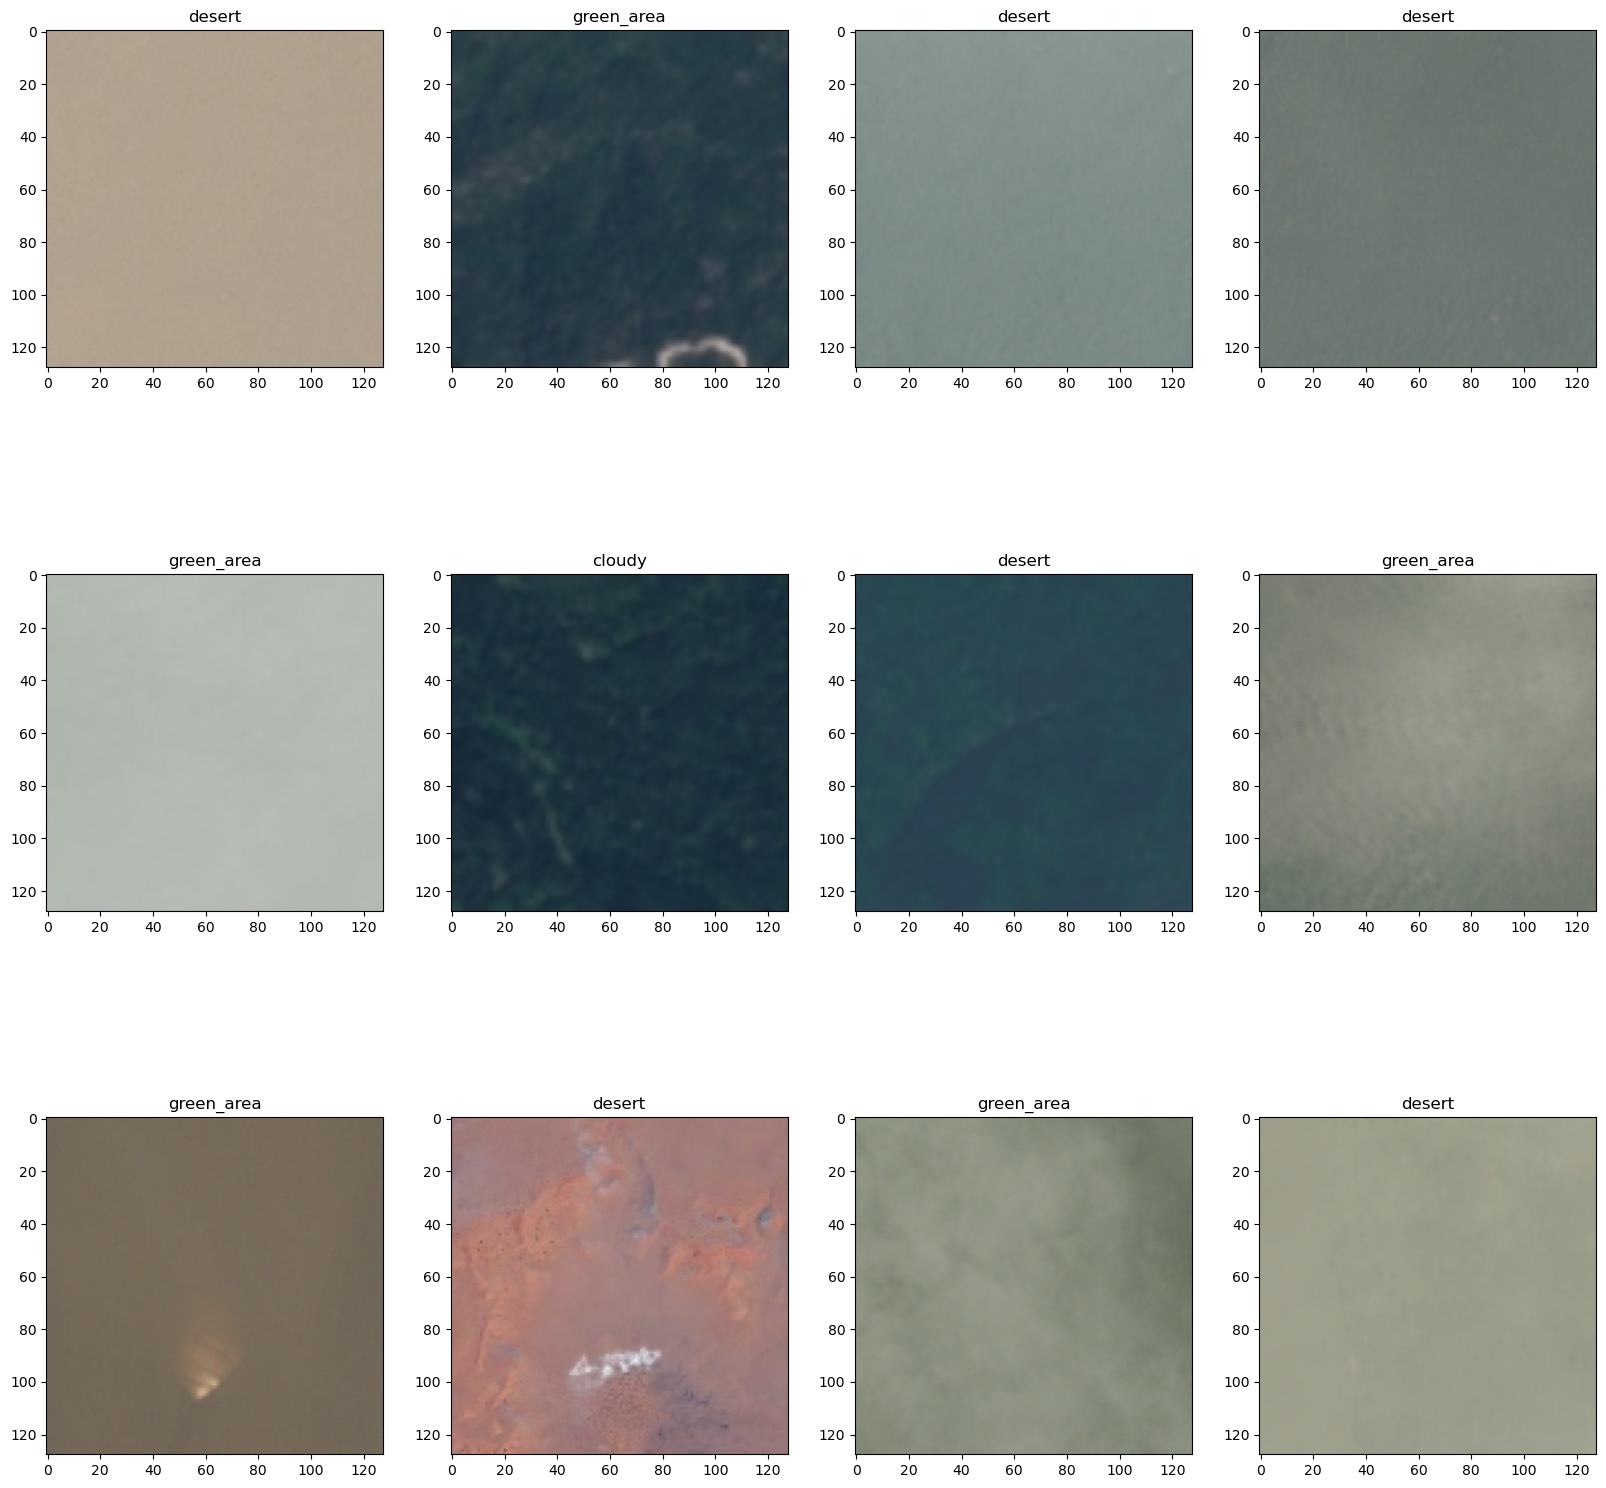

In [110]:
plt.figure(figsize=(20,20))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X_test[i])
    if label[i]==0:
        plt.title('green_area')
    elif label[i]==1:
        plt.title('desert')
    else:
        plt.title('cloudy')

### Visualizing real world image

In [120]:
test_img=plt.imread('noul_amo_2015128.jpg')

In [121]:
test_img=cv2.resize(test_img,(128,128))
test_img=np.array(test_img)


In [122]:
test_img=np.reshape(test_img,(1,128,128,3))
test_img=test_img/255.0

In [123]:
prediction1=model.predict(test_img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


In [124]:
prediction1

array([[9.1051948e-01, 9.6062267e-06, 8.9470826e-02]], dtype=float32)

In [125]:
pred1=np.argmax(prediction1,axis=1)

In [126]:
pred1

array([0])

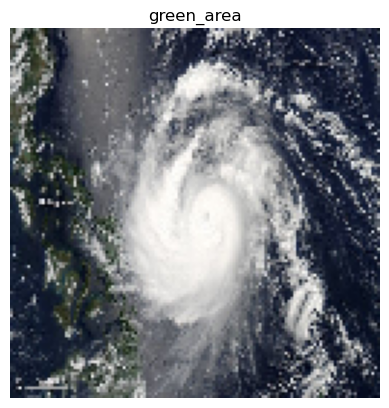

In [127]:
label_dict = {0:'green_area',1:'desert',2:'cloudy'}

plt.imshow(test_img[0])
plt.title(label_dict[pred1[0]])
plt.axis("off")
plt.show()